# (0) Imports and Loading Paths

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from pennylane import numpy as pnp
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers

In [5]:
base = "/Users/e.d./ETH/8. Quantum Hackathon/Dataset_1/option1_nf_unsw_dos_as_ddos"
benign_train_dir = base + "/normal" + "/train"
benign_test_dir = base + "/normal" + "/test"
attack_train_dir = base + "/attack" + "/train"
attack_test_dir = base + "/attack" + "/test"
benign_train_dir = Path(benign_train_dir)
attack_train_dir = Path(attack_train_dir)
benign_test_dir = Path(benign_test_dir)
attack_test_dir = Path(attack_test_dir)

bin_size_ms = 1000 # 1-second bins

In [6]:
# Loads file at path into df and bins flows according to flow start time into bins of size bin_size
def load_and_bin_data(path, bin_size = bin_size_ms):
    df = pd.read_csv(path, low_memory = False)
    df["time_bin"] = df["FLOW_START_MILLISECONDS"] // bin_size * bin_size
    
    t_min_ms = int(df['FLOW_START_MILLISECONDS'].min() // bin_size * bin_size)
    t_max_ms = int(df['FLOW_START_MILLISECONDS'].max() // bin_size * bin_size)
    
    full_time_axis = np.arange(t_min_ms, t_max_ms + bin_size, bin_size)
    t_axis = (full_time_axis - t_min_ms) / 1000  # seconds from start

    return df, t_axis, t_min_ms

## (1) Compute Feature Matrix and Show DDoS

In [7]:
# Dictionaty containing sign of increase during anomaly
feature_sign = {
    'total_packets':    +1,
    'n_src_ips':        +1,
    'n_dst_ips':        -1,
    'n_dst_ports':      -1,
    'mean_pkts_per_s':  +1,
    'mean_bytes_per_s': +1,
}

feature_names = list(feature_sign.keys())
num_features = len(feature_names)
sign_vec = np.array([feature_sign[f] for f in feature_names], dtype = float)

def compute_feature_matrix(df, t_axis, t_min_ms):
    
    T = len(t_axis)
    full_time_axis = (t_axis * 1000 + t_min_ms).astype(int)
    
    df = df.copy()
    
    df['total_packets'] = df['IN_PKTS']  + df['OUT_PKTS']
    df['total_bytes'] = df['IN_BYTES'] + df['OUT_BYTES']
    df['duration_s'] = df['FLOW_DURATION_MILLISECONDS'] / 1000.0
    df['pkt_size'] = (df['total_bytes'] / df['total_packets'].replace(0, np.nan))
    df['pkts_per_s'] = (df['total_packets'] / df['duration_s'].replace(0, np.nan))
    df['bytes_per_s'] = (df['total_bytes'] / df['duration_s'].replace(0, np.nan))
    
    grp = df.groupby('time_bin')
    
    total_packets = grp['total_packets'].sum().reindex(full_time_axis, fill_value=0)
    n_src_ips     = grp['IPV4_SRC_ADDR'].nunique().reindex(full_time_axis, fill_value=0)
    n_dst_ips     = grp['IPV4_DST_ADDR'].nunique().reindex(full_time_axis, fill_value=0)
    n_dst_ports   = grp['L4_DST_PORT'].nunique().reindex(full_time_axis, fill_value=0)

    # ── mean features (forward-fill then back-fill missing bins) ─────────────
    mean_pkts_per_s  = (grp['pkts_per_s'].mean().reindex(full_time_axis).ffill().bfill().fillna(0))
    mean_bytes_per_s = (grp['bytes_per_s'].mean().reindex(full_time_axis).ffill().bfill().fillna(0))
    
    feature_matrix = np.stack([
        total_packets.values,
        n_src_ips.values,
        n_dst_ips.values,
        n_dst_ports.values,
        mean_pkts_per_s.values,
        mean_bytes_per_s.values,
    ], axis=1).astype(np.float32)   # shape: (T, 9)

    # apply sign convention: multiply each column by its sign
    feature_matrix = feature_matrix * sign_vec[np.newaxis, :]

    return feature_matrix

In [8]:
burst_colors = ['red', 'orange', 'cyan', 'lime']

def add_burst_shading(ax, burst_iv):

    for _, row in burst_iv.iterrows():
        bid   = int(row['burst_id'])
        color = burst_colors[(bid - 1) % len(burst_colors)]
        ax.axvspan(row['t_start_s'], row['t_end_s'], alpha=0.2, color=color, label=f'Burst {bid}')
        ax.axvline(row['t_start_s'], color=color, lw=1.0, linestyle='--')
        ax.axvline(row['t_end_s'],   color=color, lw=1.0, linestyle='--')

def extract_burst_intervals(df, t_min_ms):
    
    burst_rows = df[df['is_seeded_ddos'] == 1]
    if burst_rows.empty:
        return pd.DataFrame(columns=['burst_id', 't_start_s', 't_end_s'])

    iv = (burst_rows.groupby('burst_id')['FLOW_START_MILLISECONDS']
                    .agg(['min', 'max'])
                    .reset_index())
    iv['t_start_s'] = (iv['min'] - t_min_ms) / 1000
    iv['t_end_s']   = (iv['max'] - t_min_ms) / 1000
    return iv

In [9]:
def build_benign_baseline(benign_dir, bin_size = bin_size_ms):
    
    matrices = []

    for path in sorted(benign_dir.glob("*.csv")):
        print(f"  loading {path.name}...")
        df, t_axis, t_min_ms = load_and_bin_data(path, bin_size)
        mat = compute_feature_matrix(df, t_axis, t_min_ms)
        matrices.append(mat)

    # align to shortest file (all should be 900 bins but just in case)
    min_T = min(m.shape[0] for m in matrices)
    stack = np.stack([m[:min_T] for m in matrices], axis=0)  # (n_files, T, F)

    mu_array = stack.mean(axis=0)   # (T, F)
    sigma_array = stack.std(axis=0)    # (T, F)

    # avoid division by zero in bins where all files agree exactly
    sigma_array = np.where(sigma_array < 1e-6, 1.0, sigma_array)
    
    return mu_array.astype(np.float32), sigma_array.astype(np.float32)

def compute_zscore_image(path, mu_array, sigma_array, bin_size = bin_size_ms, clip = 5.0):

    df, t_axis, t_min_ms = load_and_bin_data(path, bin_size)
    feat_mat = compute_feature_matrix(df, t_axis, t_min_ms)

    T = min(feat_mat.shape[0], mu_array.shape[0])
    z_raw  = (feat_mat[:T] - mu_array[:T]) / sigma_array[:T]           # (T, F)

    # clip and normalise to [0,1] for downstream use
    z_clipped = np.clip(z_raw, -clip, clip)
    z_norm    = (z_clipped + clip) / (2 * clip)

    return z_raw, z_norm, t_axis[:T], df

  loading normal_train_01.csv...
  loading normal_train_02.csv...
  loading normal_train_03.csv...
  loading normal_train_04.csv...
  loading normal_train_05.csv...
  loading normal_train_06.csv...
  loading normal_train_07.csv...
  loading normal_train_08.csv...
Burst intervals:
   burst_id  t_start_s  t_end_s
0       1.0    635.031  652.905
1       2.0    680.031  697.959
2       3.0    825.597  843.507
3       4.0    858.888  876.771


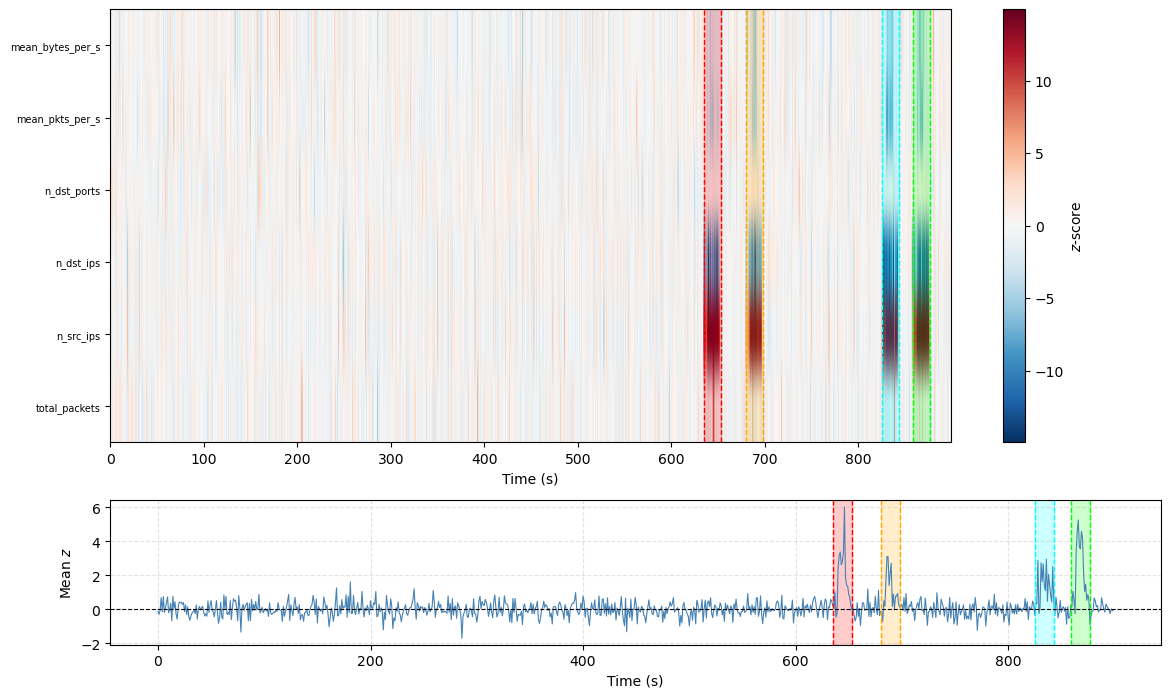

In [10]:
def plot_zscore_image(z_raw, t_axis, burst_iv=None, title=""):
    
    cm = 1/2.54
    
    fig, axes = plt.subplots(2, 1, figsize=(30*cm, 18*cm), gridspec_kw={'height_ratios': [3, 1]})
    
    # panel 1: z-score heatmap
    vmax = np.percentile(np.abs(z_raw), 99)
    im = axes[0].imshow(
        z_raw.T,
        aspect='auto',
        origin='lower',
        extent=[t_axis[0], t_axis[-1], -0.5, num_features - 0.5],
        cmap='RdBu_r',
        vmin=-vmax, vmax=vmax
    )
    axes[0].set_yticks(np.arange(num_features))
    axes[0].set_yticklabels(feature_names, fontsize=7)
    axes[0].set_xlabel("Time (s)")
    plt.colorbar(im, ax=axes[0], label="$z$-score")
    
    if burst_iv is not None:                   
        add_burst_shading(axes[0], burst_iv)

    # panel 2: mean z-score across features
    mean_z = z_raw.mean(axis=1)
    axes[1].plot(t_axis, mean_z, color='steelblue', lw=0.8)
    axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
    axes[1].set_ylabel(r"Mean $z$")
    axes[1].set_xlabel("Time (s)")
    axes[1].xaxis.grid(alpha=0.35, linestyle='dashed')
    axes[1].yaxis.grid(alpha=0.35, linestyle='dashed')
    
    if burst_iv is not None:                     
        add_burst_shading(axes[1], burst_iv)

    plt.tight_layout()
    plt.show()


# Build benign baseline
mu, sigma = build_benign_baseline(benign_train_dir)

attack_path = attack_train_dir / "attack_train_04.csv"
z_raw, z_norm, t_axis, df_attack = compute_zscore_image(attack_path, mu, sigma)

t_min_ms  = int(df_attack['FLOW_START_MILLISECONDS'].min() // bin_size_ms * bin_size_ms)
burst_iv  = extract_burst_intervals(df_attack, t_min_ms) 

print(f"Burst intervals:\n{burst_iv[['burst_id', 't_start_s', 't_end_s']]}")

plot_zscore_image(z_raw, t_axis, burst_iv=burst_iv, title=f"z-score image — {attack_path.name}")

## (2) Quanvolution with Random Circuit

In [95]:
PATCH_T = 2    # patch width  in time dimension
PATCH_F = 3    # patch height in feature dimension
N_QUBITS = PATCH_T * PATCH_F   # = 6  (derived, do not set manually)
N_LAYERS = 3    # depth of the random entangling circuit
N_CHANNELS = 4    # number of independent random circuits = output channels

dev = qml.device("lightning.qubit", wires=N_QUBITS)

np.random.seed(42)
rand_params = np.random.uniform(
    high=2 * np.pi,
    size=(N_CHANNELS, N_LAYERS, N_QUBITS)
)

In [96]:
@qml.qnode(dev)
def circuit(phi, channel):
    
    # angle encoding
    for j in range(N_QUBITS):
        qml.RY(np.pi * phi[j], wires=j)

    # random entangling circuit
    RandomLayers(rand_params[channel], wires=list(range(N_QUBITS)))

    # measure Z on each qubit
    return [qml.expval(qml.PauliZ(j)) for j in range(N_QUBITS)]

# Takes image shape (T, F), values in [0, 1] and returns shape (T - PATCH_T + 1, F - PATCH_F + 1, N_CHANNELS * N_QUBITS)
def quanvolutional_layer(image):

    T, F   = image.shape
    T_out  = T - PATCH_T + 1
    F_out  = F - PATCH_F + 1
    n_out  = N_CHANNELS * N_QUBITS

    output = np.zeros((T_out, F_out, n_out))
    total  = T_out * F_out
    count  = 0

    for t in range(T_out):
        for f in range(F_out):
            patch = image[t:t + PATCH_T, f:f + PATCH_F].flatten()  # (N_QUBITS,)

            channel_responses = []
            for c in range(N_CHANNELS):
                resp = circuit(patch, c)
                channel_responses.append(np.array(resp))

            output[t, f, :] = np.concatenate(channel_responses)

            count += 1
            if count % 200 == 0:
                print(f"  patch {count}/{total}", end='\r')

    print(f"  done: {total} patches processed")
    return output

# Takes output of quanvolution layer with shape shape (T_out, F_out, N_CHANNELS * N_QUBITS) and returns shape (T_out,), z-scored anomaly score per time bin
def anomaly_score(quanv_out):
    
    neg   = -quanv_out
    score = neg.mean(axis=(1, 2))
    score = (score - score.mean()) / (score.std() + 1e-9)
    return score

In [97]:
def run_pipeline(path, mu, sigma, z_thresh=2.0, coarsen=5):
    
    print(f"   PATCH_T={PATCH_T}, PATCH_F={PATCH_F}, "f"N_QUBITS={N_QUBITS}, N_LAYERS={N_LAYERS}, "f"N_CHANNELS={N_CHANNELS}")
    
    # z-score image
    z_raw, z_norm, t_axis, df = compute_zscore_image(path, mu, sigma)
    T, F = z_norm.shape

    t_min_ms = int(df['FLOW_START_MILLISECONDS'].min() // bin_size_ms * bin_size_ms)
    burst_iv = extract_burst_intervals(df, t_min_ms)

    # coarsen time axis
    T_c      = T // coarsen
    image_c  = (z_norm[:T_c * coarsen].reshape(T_c, coarsen, F).mean(axis=1))
    t_axis_c = (t_axis[:T_c * coarsen].reshape(T_c, coarsen).mean(axis=1))

    print(f"   Image after coarsening: {image_c.shape}  "f"({T_c} bins × {F} features)")
    
    # Check if patch fits inside image
    if T_c < PATCH_T or F < PATCH_F:
        raise ValueError(
            f"Patch ({PATCH_T}×{PATCH_F}) is larger than "
            f"coarsened image ({T_c}×{F}). "
            f"Reduce PATCH_T/PATCH_F or decrease coarsen."
        )

    # quanvolutional layer
    quanv_out = quanvolutional_layer(image_c)
    print(f"   Quanv output shape: {quanv_out.shape}")

    # anomaly score
    score   = anomaly_score(quanv_out)
    t_score = t_axis_c[:len(score)]
    flagged = score > z_thresh

    # suppress false positives on flat signals:
    # if the peak of the score is less than min_prominence
    # standard deviations above the mean, nothing is flagged
    min_prominence = 4.5
    score_range    = float(score.max() - score.mean())
    if score_range < min_prominence:
        flagged = np.zeros(len(flagged), dtype=bool)
        print(f"   Suppressed: peak prominence {score_range:.2f} < {min_prominence}")
    else:
        print(f"   Peak prominence: {score_range:.2f} — keeping flags")

    # plot
    cm = 1/2.54
    fig, axes = plt.subplots(3, 1, figsize=(30*cm, 24*cm), gridspec_kw={'height_ratios': [2, 1.5, 1]})
    
    # input image
    im = axes[0].imshow(
        image_c.T,
        aspect='auto', origin='lower',
        extent=[t_axis_c[0], t_axis_c[-1], -0.5, F - 0.5],
        cmap='RdBu_r', vmin=0, vmax=1
    )
    axes[0].set_yticks(np.arange(F))
    axes[0].set_yticklabels(feature_names, fontsize=7)
    axes[0].set_xlabel("Time (s)")
    plt.colorbar(im, ax=axes[0], label="Normalised $z$-score")
    
    if not burst_iv.empty:
        add_burst_shading(axes[0], burst_iv)

    # anomaly score
    axes[1].plot(t_score, score, color='steelblue', lw=0.9)
    axes[1].axhline(z_thresh, color='red', lw=1.2, linestyle='--', label=f'Threshold $z={z_thresh}$')
    axes[1].fill_between(t_score, score, z_thresh, where=flagged, color='red', alpha=0.4, label='Flagged')
    if not burst_iv.empty:
        add_burst_shading(axes[1], burst_iv)
    axes[1].set_ylabel("Anomaly score")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend(loc='upper right', fontsize=7)
    axes[1].xaxis.grid(alpha=0.35, linestyle='dashed')
    axes[1].yaxis.grid(alpha=0.35, linestyle='dashed')
    
    fig.tight_layout()
    
        # binary output
    axes[2].fill_between(t_score, flagged.astype(int), step='mid', color='red', alpha=0.6, label='Flagged')
    if not burst_iv.empty:
        add_burst_shading(axes[2], burst_iv)
    axes[2].set_ylabel("Flagged")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_yticks([0, 1])
    axes[2].legend(loc='upper right', fontsize=7)
    axes[2].xaxis.grid(alpha=0.35, linestyle='dashed')
    axes[2].yaxis.grid(alpha=0.35, linestyle='dashed')
    
    fig.savefig("quanlayer_output.png", dpi = 200)
    return image_c, t_axis_c, score, flagged, burst_iv

   PATCH_T=2, PATCH_F=3, N_QUBITS=6, N_LAYERS=3, N_CHANNELS=4
   Image after coarsening: (180, 6)  (180 bins × 6 features)
  done: 716 patches processed
   Quanv output shape: (179, 4, 24)
   Suppressed: peak prominence 4.06 < 4.5


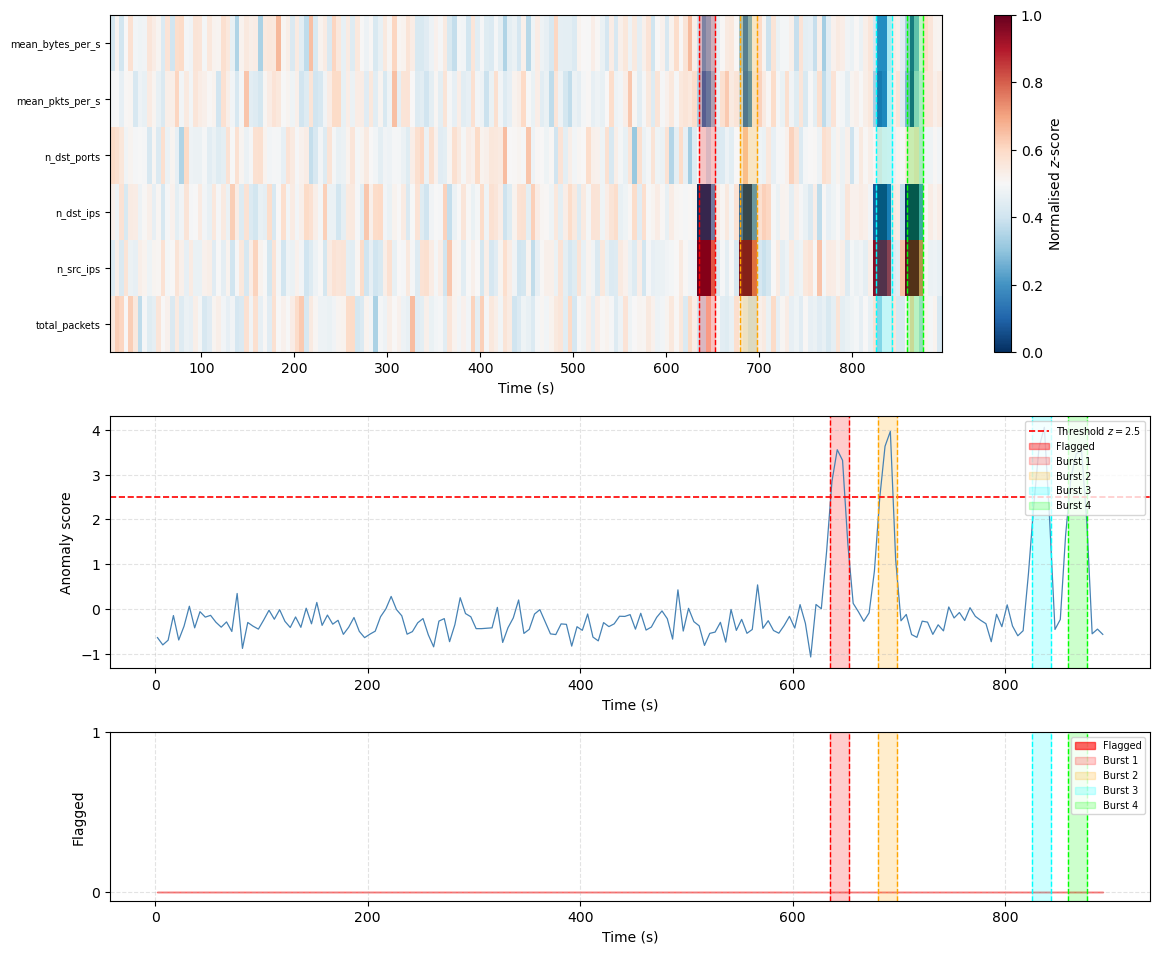

In [100]:
file_path = attack_train_dir / "attack_train_04.csv"

image_c, t_c, score, flagged, burst_iv = run_pipeline(
    file_path,
    mu, sigma,
    z_thresh = 2.5,
    coarsen  = 5
)

In [39]:
import itertools

def flagged_intervals(flagged, t_axis, coarsen = 5):

    t = t_axis[:len(flagged)]
    bin_width = coarsen  # seconds per coarsened bin

    intervals = []
    for is_flagged, group in itertools.groupby(
            enumerate(flagged), key=lambda x: x[1]):
        if is_flagged:
            indices = [i for i, _ in group]
            t_start = t[indices[0]]
            t_end   = t[indices[-1]] + bin_width  # end of last bin
            intervals.append({
                't_start_s':  t_start,
                't_end_s':    t_end,
                'duration_s': t_end - t_start
            })

    return pd.DataFrame(intervals)

detected_iv = flagged_intervals(flagged, t_c, coarsen=5)

In [40]:
flagged_intervals(flagged, t_c)

,t_start_s,t_end_s,duration_s
0,642.0,652.0,10.0
1,687.0,697.0,10.0
2,832.0,842.0,10.0
3,862.0,872.0,10.0


## (3) Training Quanvolution

In [65]:
PATCH_T = 2    # patch width  in time dimension
PATCH_F = 3    # patch height in feature dimension
N_QUBITS = PATCH_T * PATCH_F   # = 6  (derived, do not set manually)
N_LAYERS = 1    # depth of the random entangling circuit
N_CHANNELS = 1    # number of independent random circuits = output channels

dev = qml.device("lightning.qubit", wires=N_QUBITS)

np.random.seed(42)
rand_params = np.random.uniform(
    high=2 * np.pi,
    size=(N_CHANNELS, N_LAYERS, N_QUBITS)
)

In [75]:
X_list = []
y_list = []

# benign files → all bins labelled 0
for path in sorted(benign_train_dir.glob("*.csv")):
    z_raw, z_norm, t_axis, df = compute_zscore_image(path, mu, sigma)
    labels = np.zeros(len(t_axis), dtype=np.float32)
    X_list.append(z_norm)
    y_list.append(labels)

# attack files → bins labelled 1 where burst occurs
for path in sorted(attack_train_dir.glob("*.csv")):
    z_raw, z_norm, t_axis, df = compute_zscore_image(path, mu, sigma)
    t_min_ms = int(df['FLOW_START_MILLISECONDS'].min() // bin_size_ms * bin_size_ms)
    burst_iv = extract_burst_intervals(df, t_min_ms)

    labels = np.zeros(len(t_axis), dtype=np.float32)
    for _, row in burst_iv.iterrows():
        mask = (t_axis >= row['t_start_s']) & (t_axis <= row['t_end_s'])
        labels[mask] = 1.0

    X_list.append(z_norm)
    y_list.append(labels)

X_train = np.array(X_list)   # list of 16 arrays, each shape (T, F)
y_train = np.array(y_list)   # list of 16 arrays, each shape (T,)

# shuffle consistently so X and y stay aligned
rng = np.random.default_rng(seed=42)
idx = rng.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

## Simple BCE Loss Old Circuit

In [67]:
@qml.qnode(dev, interface="autograd", diff_method="parameter-shift")
def circuit(phi, theta):
    """
    phi   : shape (N_QUBITS,)          — input patch, fixed
    theta : shape (N_LAYERS, N_QUBITS) — trainable parameters
    """
    # step 1: angle encoding (same as before)
    for j in range(N_QUBITS):
        qml.RY(np.pi * phi[j], wires=j)

    # step 2: trainable entangling layers
    for l in range(N_LAYERS):
        # trainable single-qubit rotations
        for j in range(N_QUBITS):
            qml.RY(theta[l, j], wires=j)
        # fixed CNOT ring — creates entanglement
        for j in range(N_QUBITS):
            qml.CNOT(wires=[j, (j + 1) % N_QUBITS])

    # step 3: measure
    return [qml.expval(qml.PauliZ(j)) for j in range(N_QUBITS)]

# shape: (N_CHANNELS, N_LAYERS, N_QUBITS)
# use pennylane numpy so gradients can flow through
np.random.seed(42)
theta = pnp.array(
    np.random.uniform(0, 2 * np.pi,
                      size=(N_CHANNELS, N_LAYERS, N_QUBITS)),
    requires_grad=True
)

def quanvolutional_layer(image: np.ndarray,
                          theta: pnp.ndarray) -> pnp.ndarray:
    T, F   = image.shape
    T_out  = T - PATCH_T + 1
    F_out  = F - PATCH_F + 1

    # collect all patch responses as a list — do NOT pre-allocate
    # a numpy array, as it cannot hold ArrayBox objects during
    # gradient computation
    all_responses = []

    for t in range(T_out):
        row_responses = []
        for f in range(F_out):
            patch = image[t:t + PATCH_T, f:f + PATCH_F].flatten()

            channel_responses = []
            for c in range(N_CHANNELS):
                resp = circuit(patch, theta[c])          # list of N_QUBITS values
                channel_responses.append(pnp.stack(resp))

            # concatenate channels → shape (N_CHANNELS * N_QUBITS,)
            patch_out = pnp.concatenate(channel_responses)
            row_responses.append(patch_out)

        # stack along feature axis → shape (F_out, N_CHANNELS * N_QUBITS)
        all_responses.append(pnp.stack(row_responses))

    # stack along time axis → shape (T_out, F_out, N_CHANNELS * N_QUBITS)
    return pnp.stack(all_responses)


def loss_fn(theta, image_c, labels):
    quanv_out = quanvolutional_layer(image_c, theta)

    # mean over feature and channel axes → shape (T_out,)
    score = -pnp.mean(quanv_out, axis=(1, 2))

    # sigmoid
    prob  = 1.0 / (1.0 + pnp.exp(-score))

    # binary cross-entropy
    eps  = 1e-7
    bce  = -(labels * pnp.log(prob + eps) +
             (1.0 - labels) * pnp.log(1.0 - prob + eps))
    return pnp.mean(bce)

from pennylane import grad as qgrad

LEARNING_RATE = 0.05
N_EPOCHS = 5

# gradient function via parameter-shift rule
grad_fn = qgrad(loss_fn, argnums=0)

# build training data (from earlier)
# X_train: list of image_c arrays, y_train: list of label arrays

loss_history = []

for epoch in range(N_EPOCHS):
    epoch_loss = 0.0

    for image_c, labels in zip(X_train, y_train):
        print("1")
        # labels must be aligned to quanv output length
        n = image_c.shape[0] - PATCH_T + 1
        labels_aligned = pnp.array(labels[:n], requires_grad=False)
        print("2")
        # compute gradient
        grads = grad_fn(theta, image_c, labels_aligned)
        print("3")
        # gradient descent update
        theta = theta - LEARNING_RATE * grads
        print("4")
        # compute loss for monitoring
        loss_val = loss_fn(theta, image_c, labels_aligned)
        epoch_loss += float(loss_val)
        print("5")
        
    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={epoch_loss:.4f}")

# plot training curve
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Training loss")
plt.grid(alpha=0.35, linestyle='dashed')
plt.show()

1
2


KeyboardInterrupt: 

## Weighted BCE Loss Old Circuit

Random classifier baseline: 1.3401
Benign bins:  2610
Burst bins:   90
pos_weight:   29.0
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 1/20  loss=1.5317
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 2/20  loss=1.5314
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 3/20  loss=1.5311
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 4/20  loss=1.5309
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 5/20  loss=1.5306
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 6/20  loss=1.5303
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 7/20  loss=1.5300
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 8/20  loss=1.5297
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 9/20  loss=1.5293
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 10/20  loss=1.5290
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 11/20  loss=1.5286
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 12/20  loss=1.5283
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 13/20  loss=1.5279
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 14/20  loss=1.5275
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 15/20  loss=1.5271
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 16/20  loss=1.5267
1
2
3
4
5
1
2
3
4
5
1
2
3
4
5
Epoch 17/

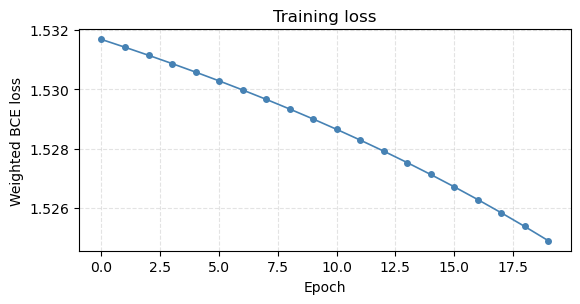

In [ ]:
# ── compute class imbalance weight from training labels ───────────────────────
n_total  = y_train.size
n_benign = float((y_train == 0).sum())
n_burst  = float((y_train == 1).sum())
pos_weight = n_benign / n_burst
baseline = np.log(2) * (pos_weight * n_burst + n_benign) / n_total
print(f"Random classifier baseline: {baseline:.4f}")

print(f"Benign bins:  {int(n_benign)}")
print(f"Burst bins:   {int(n_burst)}")
print(f"pos_weight:   {pos_weight:.1f}")

# ── quantum circuit ───────────────────────────────────────────────────────────
@qml.qnode(dev, interface="autograd", diff_method="parameter-shift")
def circuit(phi, theta):
    """
    phi   : shape (N_QUBITS,)          — input patch, fixed
    theta : shape (N_LAYERS, N_QUBITS) — trainable parameters
    """
    for j in range(N_QUBITS):
        qml.RY(np.pi * phi[j], wires=j)
    for l in range(N_LAYERS):
        for j in range(N_QUBITS):
            qml.RY(theta[l, j], wires=j)
        for j in range(N_QUBITS):
            qml.CNOT(wires=[j, (j + 1) % N_QUBITS])
    return [qml.expval(qml.PauliZ(j)) for j in range(N_QUBITS)]


# ── trainable parameters ──────────────────────────────────────────────────────
np.random.seed(42)
theta = pnp.array(
    np.random.uniform(0, 2 * np.pi,
                      size=(N_CHANNELS, N_LAYERS, N_QUBITS)),
    requires_grad=True
)


# ── quanvolutional layer ──────────────────────────────────────────────────────
def quanvolutional_layer(image, theta):
    T, F  = image.shape
    T_out = T - PATCH_T + 1
    F_out = F - PATCH_F + 1

    all_responses = []
    for t in range(T_out):
        row_responses = []
        for f in range(F_out):
            patch = image[t:t + PATCH_T, f:f + PATCH_F].flatten()
            channel_responses = []
            for c in range(N_CHANNELS):
                resp = circuit(patch, theta[c])
                channel_responses.append(pnp.stack(resp))
            patch_out = pnp.concatenate(channel_responses)
            row_responses.append(patch_out)
        all_responses.append(pnp.stack(row_responses))
    return pnp.stack(all_responses)


# ── weighted BCE loss ─────────────────────────────────────────────────────────
def weighted_bce(theta, image_c, labels, pw=pos_weight):
    """
    pw : pos_weight — how much more to penalise missed burst bins
         set to n_benign / n_burst ≈ 50 for your dataset
    """
    quanv_out = quanvolutional_layer(image_c, theta)

    # anomaly score: shape (T_out,)
    score = -pnp.mean(quanv_out, axis=(1, 2))

    # sigmoid → predicted probability of burst
    prob  = 1.0 / (1.0 + pnp.exp(-score))

    # weighted BCE
    eps   = 1e-7
    bce   = -(pw * labels * pnp.log(prob + eps) +
              (1.0 - labels) * pnp.log(1.0 - prob + eps))
    return pnp.mean(bce)


# ── coarsen helper ────────────────────────────────────────────────────────────
def coarsen_image_and_labels(z_norm, labels, coarsen=5):
    T, F  = z_norm.shape
    T_c   = T // coarsen

    image_c  = (z_norm[:T_c * coarsen]
                .reshape(T_c, coarsen, F)
                .mean(axis=1))

    # max pooling for labels: a coarsened bin is 1 if ANY
    # constituent bin contains a burst
    labels_c = (labels[:T_c * coarsen]
                .reshape(T_c, coarsen)
                .max(axis=1)
                .astype(np.float32))

    return image_c, labels_c


# ── training loop ─────────────────────────────────────────────────────────────
from pennylane import grad as qgrad

LEARNING_RATE = 0.2
N_EPOCHS      = 1
COARSEN       = 5

grad_fn = qgrad(weighted_bce, argnums=0)

loss_history = []

for epoch in range(N_EPOCHS):
    epoch_loss = 0.0

    for image_raw, labels_raw in zip(X_train, y_train):
        print("1")
        # coarsen image and labels
        image_c, labels_c = coarsen_image_and_labels(
            image_raw, labels_raw, coarsen=COARSEN
        )
        print("2")
        # align labels to quanv output length
        n              = image_c.shape[0] - PATCH_T + 1
        labels_aligned = pnp.array(labels_c[:n], requires_grad=False)
        print("3")
        # compute gradient and update
        grads = grad_fn(theta, image_c, labels_aligned)
        theta = theta - LEARNING_RATE * grads
        print("4")
        # monitor loss
        loss_val    = float(weighted_bce(theta, image_c, labels_aligned))
        epoch_loss += loss_val
        print("5")
        
    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={epoch_loss:.4f}")

# ── plot training curve ───────────────────────────────────────────────────────
cm = 1/2.54
fig, ax = plt.subplots(figsize=(15*cm, 8*cm))
ax.plot(loss_history, color='steelblue', lw=1.2, marker='o', markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted BCE loss")
ax.set_title("Training loss")
ax.xaxis.grid(alpha=0.35, linestyle='dashed')
ax.yaxis.grid(alpha=0.35, linestyle='dashed')
plt.tight_layout()
plt.show()

### New Circuit

Epoch  1/5  loss=1.5034
Epoch  2/5  loss=1.4941
Epoch  3/5  loss=1.4856
Epoch  4/5  loss=1.4776
Epoch  5/5  loss=1.4699


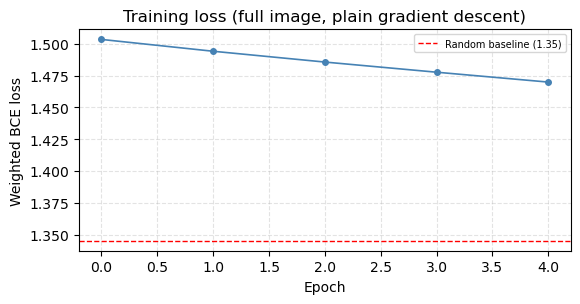

Trained parameters saved to theta_trained.npy


In [78]:
# ─────────────────────────────────────────────────────────────────────────────
# hyperparameters
# ─────────────────────────────────────────────────────────────────────────────
PATCH_T    = 2
PATCH_F    = 3
N_QUBITS   = PATCH_T * PATCH_F   # = 6
N_LAYERS   = 1
N_CHANNELS = 1
COARSEN    = 5

# ─────────────────────────────────────────────────────────────────────────────
# device and trainable parameters
# theta shape: (N_CHANNELS, N_LAYERS, 2, N_QUBITS)
# the '2' accounts for pre- and post-entanglement rotations
# ─────────────────────────────────────────────────────────────────────────────
dev = qml.device("lightning.qubit", wires=N_QUBITS)

np.random.seed(42)
theta = pnp.array(
    np.random.uniform(0, 2 * np.pi,
                      size=(N_CHANNELS, N_LAYERS, 2, N_QUBITS)),
    requires_grad=True
)

# ─────────────────────────────────────────────────────────────────────────────
# quantum circuit
# ─────────────────────────────────────────────────────────────────────────────
@qml.qnode(dev, interface="autograd", diff_method="parameter-shift")
def circuit(phi, theta):
    """
    phi   : shape (N_QUBITS,)             — input patch, fixed
    theta : shape (N_LAYERS, 2, N_QUBITS) — trainable parameters

    Structure per layer:
        1. trainable Ry rotations         (pre-entanglement)
        2. CNOT ring                      (entanglement)
        3. re-upload input                (data after entanglement)
        4. trainable Ry rotations         (post-entanglement)
    """
    for l in range(N_LAYERS):
        # 1. pre-entanglement trainable rotations
        for j in range(N_QUBITS):
            qml.RY(theta[l, 0, j], wires=j)

        # 2. CNOT ring
        for j in range(N_QUBITS):
            qml.CNOT(wires=[j, (j + 1) % N_QUBITS])

        # 3. re-upload input after entanglement
        for j in range(N_QUBITS):
            qml.RY(np.pi * phi[j], wires=j)

        # 4. post-entanglement trainable rotations
        for j in range(N_QUBITS):
            qml.RY(theta[l, 1, j], wires=j)

    return [qml.expval(qml.PauliZ(j)) for j in range(N_QUBITS)]


# ─────────────────────────────────────────────────────────────────────────────
# quanvolutional layer (no gradients needed here — used for inference)
# ─────────────────────────────────────────────────────────────────────────────
def quanvolutional_layer(image, theta):
    T, F  = image.shape
    T_out = T - PATCH_T + 1
    F_out = F - PATCH_F + 1

    all_responses = []
    for t in range(T_out):
        row_responses = []
        for f in range(F_out):
            patch = image[t:t + PATCH_T, f:f + PATCH_F].flatten()
            channel_responses = []
            for c in range(N_CHANNELS):
                resp = circuit(patch, theta[c])
                channel_responses.append(pnp.stack(resp))
            patch_out = pnp.concatenate(channel_responses)
            row_responses.append(patch_out)
        all_responses.append(pnp.stack(row_responses))
    return pnp.stack(all_responses)


# ─────────────────────────────────────────────────────────────────────────────
# weighted BCE over full image
# ─────────────────────────────────────────────────────────────────────────────
def weighted_bce(theta, image_c, labels, pw=pos_weight):
    """
    Compute weighted BCE over the full coarsened image.

    theta   : shape (N_CHANNELS, N_LAYERS, 2, N_QUBITS)
    image_c : shape (T_c, F)
    labels  : shape (T_out,)   aligned to quanv output length
    """
    quanv_out = quanvolutional_layer(image_c, theta)

    # anomaly score: shape (T_out,)
    score = -pnp.mean(quanv_out, axis=(1, 2))

    # sigmoid → predicted probability of burst
    prob  = 1.0 / (1.0 + pnp.exp(-score))

    # weighted BCE
    eps   = 1e-7
    bce   = -(pw * labels * pnp.log(prob + eps) +
              (1.0 - labels) * pnp.log(1.0 - prob + eps))
    return pnp.mean(bce)


# ─────────────────────────────────────────────────────────────────────────────
# training loop — plain gradient descent, no batches
# ─────────────────────────────────────────────────────────────────────────────
from pennylane import grad as qgrad

LEARNING_RATE = 0.2
N_EPOCHS      = 5

grad_fn      = qgrad(weighted_bce, argnums=0)
loss_history = []

for epoch in range(N_EPOCHS):
    epoch_loss = 0.0

    for image_raw, labels_raw in zip(X_train, y_train):

        # coarsen
        image_c, labels_c = coarsen_image_and_labels(image_raw, labels_raw)

        # align labels to quanv output length
        n              = image_c.shape[0] - PATCH_T + 1
        labels_aligned = pnp.array(labels_c[:n], requires_grad=False)

        # compute gradient
        grads = grad_fn(theta, image_c, labels_aligned)

        # plain gradient descent update
        theta = theta - LEARNING_RATE * grads

        # monitor loss
        loss_val    = float(weighted_bce(theta, image_c, labels_aligned))
        epoch_loss += loss_val

    epoch_loss /= len(X_train)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{N_EPOCHS}  loss={epoch_loss:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# plot training curve
# ─────────────────────────────────────────────────────────────────────────────
cm_unit = 1/2.54
fig, ax = plt.subplots(figsize=(15*cm_unit, 8*cm_unit))
ax.plot(loss_history, color='steelblue', lw=1.2, marker='o', markersize=4)
ax.axhline(baseline, color='red', lw=1.0, linestyle='--',
           label=f'Random baseline ({baseline:.2f})')
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted BCE loss")
ax.set_title("Training loss (full image, plain gradient descent)")
ax.legend(fontsize=7)
ax.xaxis.grid(alpha=0.35, linestyle='dashed')
ax.yaxis.grid(alpha=0.35, linestyle='dashed')
plt.tight_layout()
plt.show()

# save trained parameters
np.save("theta_trained.npy", np.array(theta))
print("Trained parameters saved to theta_trained.npy")